In [18]:
from pylab import *
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

## 1MN + 2H2 -> 1MT 
## 1MN + 2H2 -> 5MT      
## 5MT -> 1MT
## 1MT + 2H2 -> Cis-1MD
## 5MT + 2H2 -> Trans-1MD

In [19]:
CMN0 = linspace(1, 100, 1000) #mol/L
F5MTmax = zeros(len(CMN0))

for i, CMNi in enumerate(CMN0):

    k = array([1,2.41,0,.11,0,.94,.62,0,0,.01]) #h^-1
    T = 573.15 #K 
    v0 = 2000 #L 
    CH20 = 1.05 #mol/L
    CT0= CMNi + CH20 #mol/L
    p0 = 49.3 #atm
    FT0= 1000 # mol/h
    V0 = FT0/CT0 #L/h
    FMN0 = V0*CMNi #mol/h
    FH20 = CH20*V0 #mol/h
    rhocat = .475 #kg/L
    W0 = rhocat*v0
    
    def odefun(W,u):
        FMN, F1MT, F5MT, Ft1MD, Fc1MD = u 
        FT = FMN + FH20 + F1MT + F5MT + Ft1MD + Fc1MD

        CMN = FMN/V0 #Concentration for liquid, how does change in pressure fit into this?
        C1MT = F1MT/V0
        C5MT = F5MT/V0
        Ct1MD = Ft1MD/V0
        Cc1MD = Fc1MD/V0

        rMN = -(k[0]+k[1])*CMN 
        r1MT = k[0]*CMN + k[3]*C5MT - (k[2] + k[3] + k[5]) * C1MT	 
        r5MT = k[1]*CMN + k[3]*C1MT-(k[3]+k[6]+k[7])*C5MT
        rc1MD = k[5] * C1MT + k[7]*C5MT + k[8] * Ct1MD - k[9] * Cc1MD
        rt1MD = k[4]*C1MT + k[6]*C5MT + k[9]*Ct1MD - k[8]*Cc1MD

        dFMNdW = rMN/rhocat
        dF1MTdW = r1MT/rhocat
        dF5MTdW = r5MT/rhocat
        dFc1MDdW = rc1MD/rhocat
        dFt1MDdW = rt1MD/rhocat

        return [dFMNdW,dF1MTdW,dF5MTdW,dFc1MDdW,dFt1MDdW]
    
    u0 = array([FMN0, 0, 0, 0, 0])
    Wrange = [0, W0]
    W = linspace(*Wrange, 100)
    result = solve_ivp(odefun, Wrange, u0, t_eval = W)

    F5MT = result.y[3]
    
    F5MTmax[i] = max(F5MT)

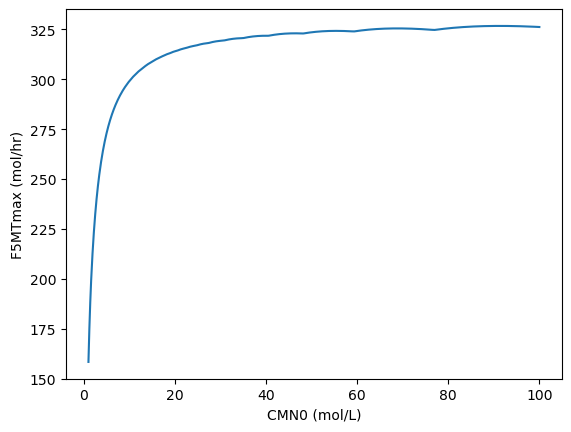

In [20]:
plot(CMN0, F5MTmax)
ylabel('F5MTmax (mol/hr)')
xlabel('CMN0 (mol/L)')
show()

In [22]:
v0 = linspace(1, 2000, 5000) #mol/L
profit = zeros(len(v0))

for i, vi in enumerate(v0):

    k = array([1,2.41,0,.11,0,.94,.62,0,0,.01]) #h^-1
    T = 573.15 #K 
    CMN0 = 25
    CH20 = 1.05 #mol/L
    CT0= CMN0 + CH20 #mol/L
    p0 = 49.3 #atm
    FT0= 1000 # mol/h
    V0 = FT0/CT0 #L/h
    FMN0 = V0*CMN0 #mol/h
    FH20 = CH20*V0 #mol/h
    rhocat = .475 #kg/L
    W0 = rhocat*vi
    
    def odefun(W,u):
        FMN, F1MT, F5MT, Ft1MD, Fc1MD = u 
        FT = FMN + FH20 + F1MT + F5MT + Ft1MD + Fc1MD

        CMN = FMN/V0 #Concentration for liquid, how does change in pressure fit into this?
        C1MT = F1MT/V0
        C5MT = F5MT/V0
        Ct1MD = Ft1MD/V0
        Cc1MD = Fc1MD/V0

        rMN = -(k[0]+k[1])*CMN 
        r1MT = k[0]*CMN + k[3]*C5MT - (k[2] + k[3] + k[5]) * C1MT	 
        r5MT = k[1]*CMN + k[3]*C1MT-(k[3]+k[6]+k[7])*C5MT
        rc1MD = k[5] * C1MT + k[7]*C5MT + k[8] * Ct1MD - k[9] * Cc1MD
        rt1MD = k[4]*C1MT + k[6]*C5MT + k[9]*Ct1MD - k[8]*Cc1MD

        dFMNdW = rMN/rhocat
        dF1MTdW = r1MT/rhocat
        dF5MTdW = r5MT/rhocat
        dFc1MDdW = rc1MD/rhocat
        dFt1MDdW = rt1MD/rhocat

        return [dFMNdW,dF1MTdW,dF5MTdW,dFc1MDdW,dFt1MDdW]
    
    u0 = array([FMN0, 0, 0, 0, 0])
    Wrange = [0, W0]
    W = linspace(*Wrange, 100)
    result = solve_ivp(odefun, Wrange, u0, t_eval = W)
    
    FMN, F1MT, F5MT, Fc1MD, Ft1MD = result.y

    idx = argmax(F5MT)   
    F5MTmax = F5MT[idx]    
    W5MTmax = W[idx]       
    F1MTmax = F1MT[idx]
    Ft1MDmax = Ft1MD[idx]
    Fc1MDmax = Fc1MD[idx]
    X = (FMN0-F5MTmax)/FMN0

    Sf = 1/X #seperation Factor
    Wcost = W5MTmax*1000*10.54
    CostMN = FMN0 * 142.2 * .24
    MH20 = FH20 * 2.016  
    vH20 = (FH20*0.0821*T)/p0
    CostH2=vH20*11.4
    Costrctns=(Wcost+CostH2+CostMN)*8765.82 

    priceF5MT = F5MTmax*146.23*930.8 #pricing down 50 percent for bulk assumption
    priceF1MT = F1MTmax*146.23*930.8
    pricec1MD = Fc1MDmax*3.09*152.28
    pricet1MD = Ft1MDmax*3.09*152.28
    revenuetotal=(priceF5MT+priceF1MT+pricec1MD+pricet1MD)*8765.82

    M1mn = FMN0 * 142.2 #mass weight
    MH20 = FH20 * 2.016

    CostEnergy1mt=FMN0*(573.15-298.15)*224.39*8765.82
    CostEnergyH2=FH20*(573.15-298.15)*28.84*8765.82
    CostEnergy=(CostEnergy1mt+CostEnergyH2)/1000

    if vi <= 20:
        CostRctr = 30000
        Costperyear = (.1*CostRctr+Costrctns+CostEnergy)*Sf
        profit[i] = revenuetotal - Costperyear
    elif 20 < vi <= 200:
        CostRctr = 40000
        Costperyear = (.1*CostRctr+Costrctns+CostEnergy)*Sf
        profit[i] = revenuetotal - Costperyear
    elif 200 < vi <= 2000:
        CostRctr = 75000
        Costperyear = (.1*CostRctr+Costrctns+CostEnergy)*Sf
        profit[i] = revenuetotal - Costperyear
    else:
        CostRctr = 300000
        Costperyear = (.1*CostRctr+Costrctns+CostEnergy)*Sf
        profit[i] = revenuetotal - Costperyear

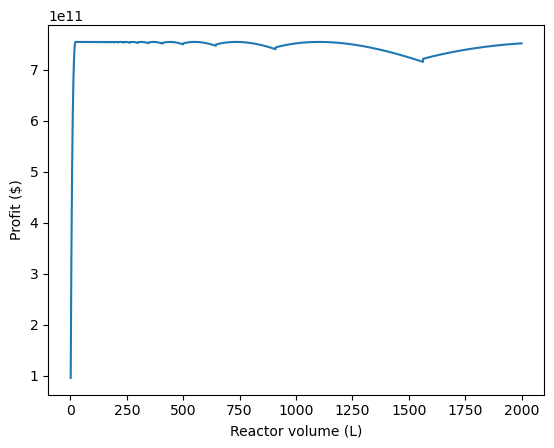

In [23]:
plot(v0, profit)
ylabel('Profit ($)')
xlabel('Reactor volume (L)')
show()